<a href="https://colab.research.google.com/github/suraj-75/laughing-train/blob/main/Optimizing_Face_Detection_and_Recognition_using_OpenCV_with_PCA_and_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip database_face.zip

unzip:  cannot find or open database_face.zip, database_face.zip.zip or database_face.zip.ZIP.


In [2]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [3]:
def load_dataset(data_dir, img_size=(100, 100)):

  x = []
  y = []

  for label in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, label)
    if os.path.isdir(class_dir) and label.startswith("Per"):
      print(f"Processing class: {label}")
      for file in os.listdir(class_dir):
        file_path = os.path.join(class_dir, file)

        img = cv2.imread(file_path)
        if img is None:
          continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, img_size)

        x.append(resized.flatten())
        y.append(label)

  x = np.array(x)
  y = np.array(y)

  return x, y

In [4]:
def load_testimages(test_img, img_size=(100, 100)):

  x_test = []
  image_names = []

  for file in os.listdir(test_dir):
    file_path = os.path.join(test_dir, file)

    img = cv2.imread(file_path)
    if img is None:
      continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, img_size)

    x_test.append(resized.flatten())
    image_names.append(file)

  x_test = np.array(x_test)

  return x_test, image_names

In [5]:
import os
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data_dir = "./database_face"
test_dir = os.path.join(data_dir, "test")

imgsize = (100, 100)

x, y = load_dataset(data_dir, imgsize)

df_x = pd.DataFrame(x)
df_y = pd.DataFrame(y, columns=['label'])

df = pd.concat([df_x, df_y], axis=1)

from IPython.display import display
display(df_x)
display(df_y)

Processing class: Per_1
Processing class: Per_3
Processing class: Per_2


,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,254,254,253,253,253,253,253,253,254,253,...,58,73,33,32,33,42,65,107,80,71
1,209,209,209,209,210,210,210,210,210,211,...,124,114,105,100,102,108,130,157,165,165
2,204,197,191,186,184,181,172,152,103,90,...,214,223,189,204,204,184,173,179,139,171
3,91,91,91,90,89,87,86,86,86,86,...,195,194,187,211,228,227,214,209,219,226
4,219,220,220,222,227,184,193,171,151,177,...,148,138,138,136,178,177,176,173,151,159
5,224,227,216,212,221,222,218,217,219,221,...,227,219,223,216,225,219,224,220,228,240
6,137,137,139,139,139,140,138,137,138,136,...,128,129,119,103,94,91,103,104,107,112
7,158,159,153,162,160,159,164,166,166,162,...,83,133,98,80,95,106,109,114,118,118
8,196,198,199,198,198,199,199,199,198,198,...,59,48,57,73,100,82,74,71,73,38
9,162,154,165,162,167,164,188,189,187,143,...,90,82,52,76,144,107,137,146,144,137


,label
0,Per_1
1,Per_1
2,Per_1
3,Per_1
4,Per_1
5,Per_1
6,Per_1
7,Per_3
8,Per_3
9,Per_3


In [6]:
n_components = 5
pca = PCA(n_components=n_components, whiten=True)

# Fit PCA on the training data and transform it
x_pca = pca.fit_transform(x)
df_x_pca = pd.DataFrame(x_pca)
display(df_x_pca)

,0,1,2,3,4
0,1.845622,1.554249,-0.367761,0.205555,0.292453
1,1.118687,1.267105,-0.469270,-0.063948,0.563484
2,-0.464325,-1.071643,-0.073341,-2.433108,0.315192
3,-0.198840,-0.157632,-1.557885,0.511270,-0.007474
4,0.209479,0.501682,1.447183,-2.123177,-2.208596
5,0.948059,0.617171,0.023243,-1.282564,2.467075
6,-0.629230,-0.650569,-0.303151,-0.657367,0.580666
7,0.267944,0.028736,1.209713,0.746021,-0.327233
8,1.282162,-1.539414,-0.616163,-0.161572,-0.730178
9,0.120044,-0.020959,0.594193,0.764507,-0.449378


In [7]:
x_test, image_names = load_testimages(test_dir, imgsize)
df_x_test = pd.DataFrame(x_test)
display(df_x_test)

x_test_pca = pca.transform(x_test)
df_x_test_pca = pd.DataFrame(x_test_pca)
display(df_x_test_pca)



,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,200,202,203,202,201,197,197,188,199,203,...,69,72,70,76,76,74,76,86,81,87
1,129,178,171,155,125,111,101,95,119,78,...,225,207,235,231,115,231,125,244,231,230
2,92,154,184,35,140,152,32,132,123,178,...,204,198,202,205,201,199,198,198,199,194
3,139,133,208,173,170,120,143,188,167,146,...,217,218,219,221,223,221,220,220,213,195
4,136,134,133,129,125,127,122,122,123,121,...,76,75,68,71,73,73,75,81,74,59
5,148,182,167,168,162,111,107,115,112,119,...,96,95,95,91,97,96,90,86,82,90


,0,1,2,3,4
0,0.183037,0.075016,0.128921,0.483499,-0.395718
1,-0.082204,-1.511015,-0.790463,-1.392970,0.614633
2,0.127517,-0.785214,-0.085579,0.344444,0.747945
3,0.781463,0.945596,-0.327398,-0.031347,-0.178667
4,-1.297680,-1.333373,0.293997,-0.679850,-0.663456
5,-0.711406,0.273737,0.588328,-0.022499,-0.436338


please upload an image to classify


Saving IMG_20250701_015111.jpg to IMG_20250701_015111.jpg


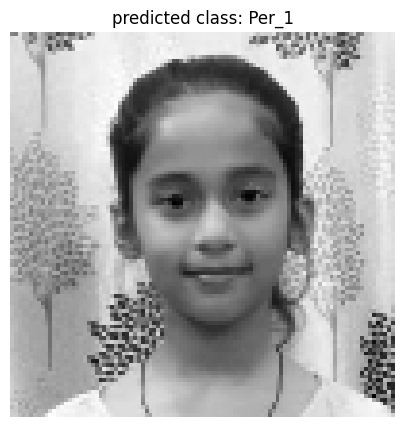

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_pca, y)

def load_image(image_path, img_size):
  img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
  if img is None:
    print(f"Error loading image: {image_path}")
    return None, None
  resized = cv2.resize(img, img_size)
  return resized.flatten(), resized

print("please upload an image to classify")
upload = files.upload()

if upload:
  image_path = list(upload.keys())[0]
  img_size = (100, 100)

  test_image_flattened, test_image_original = load_image(image_path, img_size)

  if test_image_flattened is not None and test_image_original is not None:
    test_image_pca = pca.transform(test_image_flattened.reshape(1, -1))

    predicted_class = knn.predict(test_image_pca)[0]
    plt.figure(figsize=(5,5))
    plt.imshow(test_image_original, cmap='gray')
    plt.title(f"predicted class: {predicted_class}")
    plt.axis('off')
    plt.show()
  else:
    print("failed to load image")
else:
    print("No file was uploaded.")